In [1]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from tqdm import tqdm
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from sklearn.cluster import KMeans

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {torch.cuda.get_device_name(0)}')

Using device: NVIDIA GeForce RTX 5060 Ti


In [2]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True)

set_seed(SEED)


## 1. Data Loading

Load hyperspectral data and treat each pixel as an independent sample.
NO spatial context is used.

In [3]:
def load_hsi_data(data_path):
    """Load HSI data from ENVI format."""
    import spectral
    img = spectral.open_image(data_path)
    data = img.load()
    return np.array(data, dtype=np.float32)

def load_label(label_path):
    """Load label data."""
    return np.load(label_path)

def calibrate_hsi(data, white_ref_path, dark_ref_path):
    """Calibrate HSI data using white and dark references."""
    import spectral
    white_ref = np.array(spectral.open_image(white_ref_path).load(), dtype=np.float32)
    dark_ref = np.array(spectral.open_image(dark_ref_path).load(), dtype=np.float32)
    
    # Average across spatial dimensions
    white_mean = white_ref.mean(axis=(0, 1))
    dark_mean = dark_ref.mean(axis=(0, 1))
    
    # Calibration
    calibrated = (data - dark_mean) / (white_mean - dark_mean + 1e-8)
    calibrated = np.clip(calibrated, 0, 1)
    
    return calibrated

In [4]:
class HSIPixelDataset(Dataset):
    """Dataset that treats each pixel as an independent sample."""
    
    def __init__(self, data, labels=None):
        """
        Args:
            data: HSI data of shape (H, W, B)
            labels: Label array of shape (H, W) or None
        """
        self.data = data
        self.labels = labels
        
        # Flatten spatial dimensions
        #H, W, B = data.shape
        self.pixels = self.data
        
        if labels is not None:
            self.pixel_labels = labels
        else:
            self.pixel_labels = None
        
        self.shape = (H, W)
    
    def __len__(self):
        return len(self.pixels)
    
    def __getitem__(self, idx):
        pixel = torch.from_numpy(self.pixels[idx]).float()
        
        if self.pixel_labels is not None:
            label = torch.tensor(self.pixel_labels[idx], dtype=torch.long)
            return pixel, label
        else:
            return pixel

In [5]:
# Load data for a specific food type
food_type = 'Almond'  # Change to 'Pistachio' or 'GarlicStems' as needed

base_path = f'../..//AnomalyonFood/Dataset/{food_type}'


# Load training data (normal only)
train_data_path = f'{base_path}/Train/data.hdr'
train_white_path = f'{base_path}/Train/WHITEREF.hdr'
train_dark_path = f'{base_path}/Train/DARKREF.hdr'

print(f'Loading {food_type} training data...')
train_data = load_hsi_data(train_data_path)
train_data = calibrate_hsi(train_data, train_white_path, train_dark_path)

#WN: coba hanya menggunakan X% data training
H, W, B = train_data.shape
train_data = train_data.reshape(-1, B)


X_train, X_test = train_test_split(train_data, test_size=0.7, random_state=42)

# Load test data (normal + anomalies)
test_data_path = f'{base_path}/Test/data.hdr'
test_white_path = f'{base_path}/Test/WHITEREF.hdr'
test_dark_path = f'{base_path}/Test/DARKREF.hdr'
test_label_path = f'{base_path}/Test/label.npy'


print(f'Loading {food_type} test data...')
test_data = load_hsi_data(test_data_path)
test_data = calibrate_hsi(test_data, test_white_path, test_dark_path)
test_labels = load_label(test_label_path)

H, W, B = test_data.shape
test_data = test_data.reshape(-1, B)
test_labels=test_labels.reshape(-1)

print(f'Train data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')
print(f'Test labels shape: {test_labels.shape}')
print(f'Number of bands: {train_data.shape[1]}')

Loading Almond training data...


/home/alfi/miniforge3/envs/torch/lib/python3.13/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


Loading Almond test data...
Train data shape: (204800, 224)
Test data shape: (204800, 224)
Test labels shape: (204800,)
Number of bands: 224


In [6]:
# Create datasets
train_dataset = HSIPixelDataset(X_train)
test_dataset = HSIPixelDataset(test_data, test_labels)

print(f'Training pixels: {len(train_dataset)}')
print(f'Test pixels: {len(test_dataset)}')
print(f'Spectrum dimension: {train_dataset.pixels.shape[1]}')

# Create dataloaders
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8)

Training pixels: 61440
Test pixels: 204800
Spectrum dimension: 224


## 2. PA2E Model Architecture

### Components:
1. **Sliding Window Extractor** (masked FC, non-trainable)
2. **Partial Encoders** (independent FC per window)
3. **Aggregate Encoder** (single FC layer)
4. **Decoder** (mirror of encoder, used only during training)

In [7]:
class SlidingWindowExtractor(nn.Module):
    """Extract sliding windows using masked FC (not convolution)."""
    
    def __init__(self, input_dim, window_size, stride):
        super().__init__()
        self.input_dim = input_dim
        self.window_size = window_size
        self.stride = stride
        
        # Calculate number of windows
        self.num_windows = 1 + (input_dim - window_size) // stride
        
        # Create fixed extraction matrix (non-trainable)
        # This is essentially an identity matrix that extracts windows
        self.register_buffer('extract_matrix', self._create_extract_matrix())
    
    def _create_extract_matrix(self):
        """Create a matrix that extracts sliding windows."""
        matrix = torch.zeros(self.num_windows * self.window_size, self.input_dim)
        
        for i in range(self.num_windows):
            start_idx = i * self.stride
            end_idx = start_idx + self.window_size
            
            # Set the corresponding block to identity
            for j in range(self.window_size):
                matrix[i * self.window_size + j, start_idx + j] = 1.0
        
        return matrix
    
    def forward(self, x):
        """
        Args:
            x: (batch, input_dim)
        Returns:
            windows: (batch, num_windows, window_size)
        """
        # Extract windows via matrix multiplication
        windows = torch.matmul(x, self.extract_matrix.t())  # (batch, num_windows * window_size)
        
        # Reshape to separate windows
        batch_size = x.size(0)
        windows = windows.view(batch_size, self.num_windows, self.window_size)
        
        return windows

In [8]:
class PartialEncoders(nn.Module):
    """Independent encoders for each window (block-diagonal masked FC)."""
    
    def __init__(self, num_windows, window_size, hidden_dims, latent_local_dim):
        super().__init__()
        self.num_windows = num_windows
        self.window_size = window_size
        self.hidden_dims = hidden_dims
        self.latent_local_dim = latent_local_dim
        
        # Create independent encoders for each window
        # Using ModuleList to ensure proper registration
        self.encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(window_size, hidden_dims[0]),
                nn.BatchNorm1d(hidden_dims[0]),
                nn.Linear(hidden_dims[0], hidden_dims[1]),
                nn.BatchNorm1d(hidden_dims[1]),
                nn.Linear(hidden_dims[1], hidden_dims[2]),
                nn.BatchNorm1d(hidden_dims[2]),
                nn.Linear(hidden_dims[2], hidden_dims[3]),
                nn.BatchNorm1d(hidden_dims[3]),
                nn.ReLU(),
                nn.Linear(hidden_dims[3], hidden_dims[4]),
                nn.BatchNorm1d(hidden_dims[4]),
                nn.ReLU(),
                nn.Linear(hidden_dims[4], latent_local_dim),
            )
            for _ in range(num_windows)
        ])
    
    def forward(self, windows):
        """
        Args:
            windows: (batch, num_windows, window_size)
        Returns:
            local_latents: (batch, num_windows, latent_local_dim)
        """
        batch_size = windows.size(0)
        local_latents = []
        
        for i in range(self.num_windows):
            # Extract window i for all samples in batch
            window_i = windows[:, i, :]  # (batch, window_size)
            
            # Encode with independent encoder i
            #print ("Shape of each window: ", window_i.shape)
        
            latent_i = self.encoders[i](window_i)  # (batch, latent_local_dim)
            local_latents.append(latent_i)
        
        # Stack latents
        local_latents = torch.stack(local_latents, dim=1)  # (batch, num_windows, latent_local_dim)
        
        return local_latents

In [9]:
class PA2E(nn.Module):
    """PA2E model as described in the paper."""
    
    def __init__(self, input_dim, window_size=56, stride=14, 
                 hidden_dims=list(range(52, 32, -4)), latent_local_dim=32, latent_global_dim=64):
        super().__init__()
        
        self.input_dim = input_dim
        self.window_size = window_size
        self.stride = stride
        self.latent_global_dim = latent_global_dim
        
        # 1. Sliding window extractor (non-trainable)
        self.window_extractor = SlidingWindowExtractor(input_dim, window_size, stride)
        num_windows = self.window_extractor.num_windows
        
        print(f'Number of windows: {num_windows}')
        
        # 2. Partial encoders (independent per window)
        self.partial_encoders = PartialEncoders(num_windows, window_size, 
                                               hidden_dims, latent_local_dim)
        
        # 3. Aggregate encoder (SINGLE FC layer)
        concat_dim = num_windows * latent_local_dim
        self.aggregate_encoder = nn.Linear(concat_dim, latent_global_dim)
        
        # 4. Aggregate decoder (mirror of aggregate encoder)
        self.aggregate_decoder = nn.Linear(latent_global_dim, concat_dim)
        
        # 5. Partial decoders (mirror of partial encoders)
        self.partial_decoders = PartialDecoders(num_windows, window_size,
                                               hidden_dims, latent_local_dim)
        
        # Center for DSVDD (initialized later)
        self.register_buffer('center', torch.zeros(latent_global_dim))
        self.center_initialized = False
    
    def encode(self, x):
        """Encode input to latent representation."""
        # Extract windows
        windows = self.window_extractor(x)  # (batch, num_windows, window_size)
        
        # Encode each window independently
        local_latents = self.partial_encoders(windows)  # (batch, num_windows, latent_local_dim)
        
        # Concatenate local latents
        batch_size = x.size(0)
        z_concat = local_latents.view(batch_size, -1)  # (batch, num_windows * latent_local_dim)
        
        # Aggregate
        z = self.aggregate_encoder(z_concat)  # (batch, latent_global_dim)
        
        return z, local_latents
    
    def decode(self, z):
        """Decode latent to reconstruction."""
        # Aggregate decoder
        z_concat = self.aggregate_decoder(z)  # (batch, num_windows * latent_local_dim)
        
        # Reshape to local latents
        batch_size = z.size(0)
        num_windows = self.window_extractor.num_windows
        latent_local_dim = z_concat.size(1) // num_windows
        local_latents = z_concat.view(batch_size, num_windows, latent_local_dim)
        
        # Decode each window independently
        reconstructed_windows = self.partial_decoders(local_latents)
        
        return reconstructed_windows
    
    def forward(self, x):
        """Forward pass."""
        z, local_latents = self.encode(x)
        reconstructed_windows = self.decode(z)
        
        return z, reconstructed_windows
    
    def compute_anomaly_score(self, x):
        """Compute anomaly score as distance to center."""
        z, _ = self.encode(x)
        
        # Distance to center
        dist = torch.sum((z - self.center) ** 2, dim=1)
        
        return dist

In [10]:
class PartialDecoders(nn.Module):
    """Independent decoders for each window (mirror of partial encoders)."""
    
    def __init__(self, num_windows, window_size, hidden_dims, latent_local_dim):
        super().__init__()
        self.num_windows = num_windows
        self.window_size = window_size
        
        # Create independent decoders for each window
        self.decoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(latent_local_dim, hidden_dims[4]),
                nn.BatchNorm1d(hidden_dims[4]),
                nn.ReLU(),
                nn.Linear(hidden_dims[4], hidden_dims[3]),
                nn.BatchNorm1d(hidden_dims[3]),
                nn.Linear(hidden_dims[3], hidden_dims[2]),
                nn.BatchNorm1d(hidden_dims[2]),
                nn.Linear(hidden_dims[2], hidden_dims[1]),
                nn.BatchNorm1d(hidden_dims[1]),
                nn.Linear(hidden_dims[1], hidden_dims[0]),
                nn.BatchNorm1d(hidden_dims[0]),
                nn.Linear(hidden_dims[0], window_size),
            )
            for _ in range(num_windows)
        ])
    
    def forward(self, local_latents):
        """
        Args:
            local_latents: (batch, num_windows, latent_local_dim)
        Returns:
            reconstructed_windows: (batch, num_windows, window_size)
        """
        batch_size = local_latents.size(0)
        reconstructed = []
        
        for i in range(self.num_windows):
            latent_i = local_latents[:, i, :]  # (batch, latent_local_dim)
            recon_i = self.decoders[i](latent_i)  # (batch, window_size)
            reconstructed.append(recon_i)
        
        reconstructed = torch.stack(reconstructed, dim=1)  # (batch, num_windows, window_size)
        
        return reconstructed

In [11]:
class PA2EFT(PA2E):
    def __init__(self, pa2e: PA2E):
        # Initialize parent with same architecture parameters
        super().__init__(
            input_dim=pa2e.input_dim,
            window_size=pa2e.window_size,
            stride=pa2e.stride,
            hidden_dims=pa2e.partial_encoders.hidden_dims,
            latent_local_dim=pa2e.partial_encoders.latent_local_dim,
            latent_global_dim=pa2e.latent_global_dim,
        )
        # Copy all weights from pa2e
        self.load_state_dict(pa2e.state_dict())
    
    def encode(self, x):
        """Encode input to latent representation."""
        # Extract windows
        windows = self.window_extractor(x)  # (batch, num_windows, window_size)
        
        # Encode each window independently
        local_latents = self.partial_encoders(windows)  # (batch, num_windows, latent_local_dim)
        
        # Concatenate local latents
        batch_size = x.size(0)
        z_concat = local_latents.view(batch_size, -1)  # (batch, num_windows * latent_local_dim)
        
        # Aggregate
        z = self.aggregate_encoder(z_concat)  # (batch, latent_global_dim)
        
        return z, local_latents
    
    def decode(self, local_latents):
        """Decode latent to reconstruction."""
        
        # Decode each window independently
        reconstructed_windows = self.partial_decoders(local_latents)
        
        return reconstructed_windows
    
    def forward(self, x):
        """Forward pass."""
        z, local_latents = self.encode(x)
        reconstructed_windows = self.decode(local_latents)
        
        return z, reconstructed_windows
    
    def compute_anomaly_score(self, x):
        """Compute anomaly score as distance to center."""
        z, _ = self.encode(x)
        
        # Distance to center
        dist = torch.sum((z - self.center) ** 2, dim=1)
        
        return dist

In [12]:
# Initialize model
input_dim = train_dataset.pixels.shape[1]

model = PA2E(
    input_dim=input_dim,
    window_size=56,
    stride=14,
    #hidden_dim=128,
    latent_local_dim=28,
    latent_global_dim=32
).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Number of windows: 13
PA2E(
  (window_extractor): SlidingWindowExtractor()
  (partial_encoders): PartialEncoders(
    (encoders): ModuleList(
      (0-12): 13 x Sequential(
        (0): Linear(in_features=56, out_features=52, bias=True)
        (1): BatchNorm1d(52, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Linear(in_features=52, out_features=48, bias=True)
        (3): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): Linear(in_features=48, out_features=44, bias=True)
        (5): BatchNorm1d(44, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): Linear(in_features=44, out_features=40, bias=True)
        (7): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): ReLU()
        (9): Linear(in_features=40, out_features=36, bias=True)
        (10): BatchNorm1d(36, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (11): ReLU()


## 3. Training Procedure

### Phase 1: Pre-training (Autoencoder)
Train with reconstruction loss only to learn stable representations.

In [13]:
def compute_reconstruction_loss(model, x):
    """Compute reconstruction loss for sliding windows."""
    # Forward pass
    z, reconstructed_windows = model(x)
    
    # Extract original windows
    original_windows = model.window_extractor(x)
    
    # MSE loss
    loss = F.mse_loss(reconstructed_windows, original_windows)
    
    return loss, z

def train_phase1(model, train_loader, num_epochs=20, lr=1e-3):
    """Phase 1: Pre-training with reconstruction loss."""
    print('\n=== Phase 1: Pre-training (Autoencoder) ===')
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            x = batch.to(device)
            
            optimizer.zero_grad()
            
            # Compute reconstruction loss
            loss, _ = compute_reconstruction_loss(model, x)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}')
    
    return losses

In [14]:
def compute_L1reconstruction_loss(model, x):
    """Compute reconstruction loss for sliding windows."""
    # Forward pass
    z, reconstructed_windows = model(x)
    
    # Extract original windows
    original_windows = model.window_extractor(x)
    
    # WN: MAE loss
    loss = F.l1_loss(reconstructed_windows, original_windows)
    
    return loss, z

def train_phase1WN(model, train_loader, num_epochs=20, lr=1e-3):
    """Phase 1: Pre-training with reconstruction loss."""
    print('\n=== Phase 1: Pre-training (Autoencoder) ===')
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            x = batch.to(device)
            
            optimizer.zero_grad()
            
            # Compute reconstruction loss
            loss, _ = compute_L1reconstruction_loss(model, x)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}')
    
    return losses


=== Phase 1: Pre-training (Autoencoder) ===


Epoch 1/20: 100%|██████████| 120/120 [00:04<00:00, 28.83it/s]


Epoch 1/20, Loss: 0.413444


Epoch 2/20: 100%|██████████| 120/120 [00:03<00:00, 31.10it/s]


Epoch 2/20, Loss: 0.004893


...

Epoch 18/20, Loss: 0.000465


Epoch 19/20: 100%|██████████| 120/120 [00:03<00:00, 30.25it/s]


Epoch 19/20, Loss: 0.000431


Epoch 20/20: 100%|██████████| 120/120 [00:03<00:00, 30.36it/s]


Epoch 20/20, Loss: 0.000447


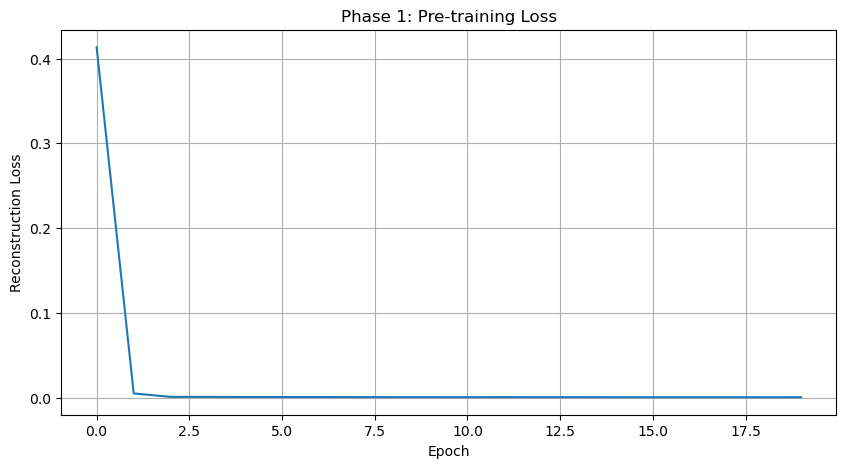

In [15]:
# Train Phase 1
phase1_losses = train_phase1(model, train_loader, num_epochs=20, lr=1e-3)

# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(phase1_losses)
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Phase 1: Pre-training Loss')
plt.grid(True)
plt.show()

### Phase 2: Main Training (DSVDD-style)

1. Compute center from training data
2. Train with combined loss: distance to center + reconstruction

In [16]:
def initialize_center(model, train_loader):
    """Compute center as mean of latent representations."""
    print('\nInitializing center...')
    
    model.eval()
    latents = []
    
    with torch.no_grad():
        for batch in tqdm(train_loader, desc='Computing center'):
            x = batch.to(device)
            z, _ = model.encode(x)
            latents.append(z)
    
    latents = torch.cat(latents, dim=0)
    center = latents.mean(dim=0)
    
    model.center = center
    model.center_initialized = True
    
    print(f'Center shape: {center.shape}')
    print(f'Center norm: {center.norm().item():.4f}')
    
    return center

In [17]:
def train_phase2(model, train_loader, num_epochs=100, lr=1e-4, alpha=0.1):
    """Phase 2: Main training with DSVDD-style loss."""
    print('\n=== Phase 2: Main Training (DSVDD-style) ===')
    
    # Initialize center
    initialize_center(model, train_loader)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    center_losses = []
    recon_losses = []
    
    for epoch in range(num_epochs):
        #initialize_center(model, train_loader)
        model.train()
        epoch_loss = 0
        epoch_center_loss = 0
        epoch_recon_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            x = batch.to(device)
            
            optimizer.zero_grad()
            
            # Compute reconstruction loss
            recon_loss, z = compute_reconstruction_loss(model, x)
            
            # Compute center loss (distance to center)
            center_loss = torch.mean(torch.sum((z - model.center) ** 2, dim=1))
            
            # Combined loss
            loss = center_loss + alpha * recon_loss
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_center_loss += center_loss.item()
            epoch_recon_loss += recon_loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        avg_center_loss = epoch_center_loss / len(train_loader)
        avg_recon_loss = epoch_recon_loss / len(train_loader)
        
        losses.append(avg_loss)
        center_losses.append(avg_center_loss)
        recon_losses.append(avg_recon_loss)
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Loss: {avg_loss:.6f}, '
              f'Center: {avg_center_loss:.6f}, '
              f'Recon: {avg_recon_loss:.6f}')
    
    return losses, center_losses, recon_losses

Number of windows: 13

=== Phase 2: Main Training (DSVDD-style) ===

Initializing center...


Computing center: 100%|██████████| 120/120 [00:00<00:00, 128.50it/s]


Center shape: torch.Size([32])
Center norm: 0.9051


Epoch 1/20: 100%|██████████| 120/120 [00:04<00:00, 29.19it/s]


Epoch 1/20, Loss: 9.649079, Center: 9.567743, Recon: 0.008134


...

Epoch 18/20, Loss: 0.013734, Center: 0.008814, Recon: 0.000492


Epoch 19/20: 100%|██████████| 120/120 [00:04<00:00, 29.96it/s]


Epoch 19/20, Loss: 0.013221, Center: 0.008258, Recon: 0.000496


Epoch 20/20: 100%|██████████| 120/120 [00:04<00:00, 29.91it/s]


Epoch 20/20, Loss: 0.012381, Center: 0.007607, Recon: 0.000477


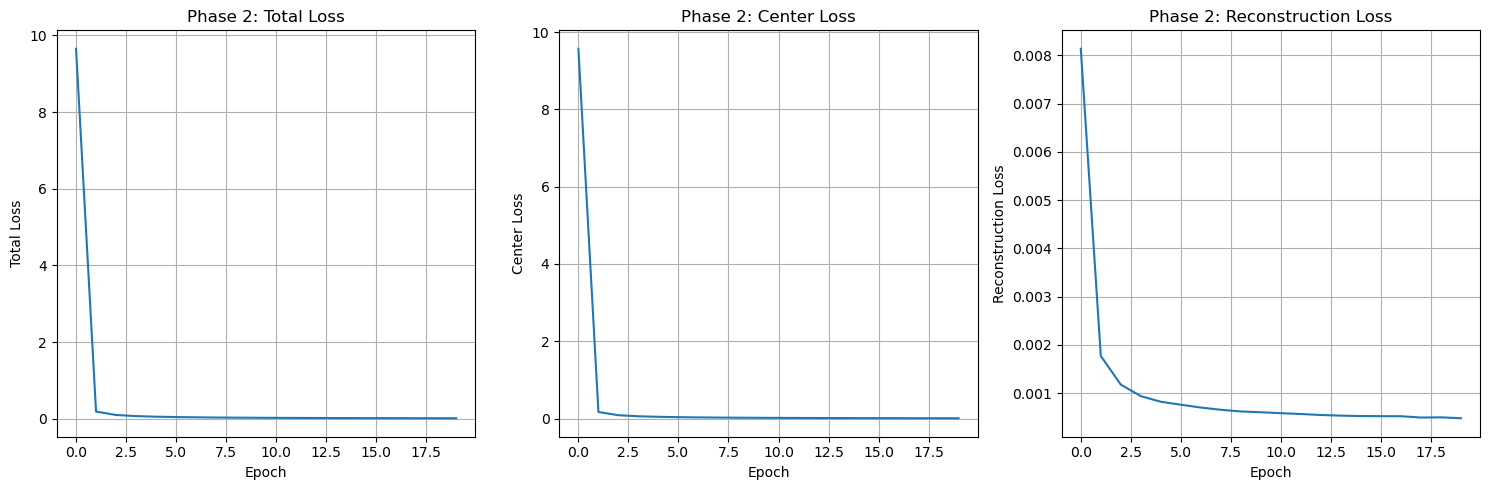

In [18]:
# Train Phase 2
model_ft = PA2EFT(model).to(device)
phase2_losses, phase2_center_losses, phase2_recon_losses = train_phase2(
    model_ft, train_loader, num_epochs=20, lr=1e-4, alpha=10
)

# Plot losses
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(phase2_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Phase 2: Total Loss')
axes[0].grid(True)

axes[1].plot(phase2_center_losses)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Center Loss')
axes[1].set_title('Phase 2: Center Loss')
axes[1].grid(True)

axes[2].plot(phase2_recon_losses)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Reconstruction Loss')
axes[2].set_title('Phase 2: Reconstruction Loss')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 4. Inference and Evaluation

Anomaly score: ||z - c||²

In [19]:
def evaluate(model, test_loader):
    """Evaluate model on test set."""
    print('\nEvaluating...')
    
    model.eval()
    all_scores = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Computing scores'):
            x, labels = batch
            x = x.to(device)
            
            # Compute anomaly scores
            scores = model.compute_anomaly_score(x)
            
            all_scores.append(scores.cpu())
            all_labels.append(labels)
    
    all_scores = torch.cat(all_scores).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    # Convert labels to binary (0=normal, 1=anomaly)
    # Assuming label 2 is normal, others are anomalies
    binary_labels = (all_labels != 2).astype(int)
    
    print(f'Normal pixels: {(binary_labels == 0).sum()}')
    print(f'Anomaly pixels: {(binary_labels == 1).sum()}')
    
    # Compute metrics
    roc_auc = roc_auc_score(binary_labels, all_scores)
    pr_auc = average_precision_score(binary_labels, all_scores)
    
    print(f'\nResults:')
    print(f'ROC-AUC: {roc_auc:.4f}')
    print(f'PR-AUC: {pr_auc:.4f}')
    
    return all_scores, binary_labels, roc_auc, pr_auc

In [ ]:
# Evaluate
from datetime import datetime

start = datetime.now()
scores, labels, roc_auc, pr_auc = evaluate(model_ft, test_loader)
end = datetime.now()
print(f'Evaluation time: {end - start}')
print(f'Average per pixel: {(end - start).total_seconds() / len(test_dataset):.6f} seconds')


Evaluating...


Computing scores: 100%|██████████| 400/400 [00:02<00:00, 142.54it/s]

Normal pixels: 201601
Anomaly pixels: 3199

Results:
ROC-AUC: 0.9790
PR-AUC: 0.8416
Evaluation time: 0:00:02.860398


/tmp/ipykernel_21818/2855274713.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


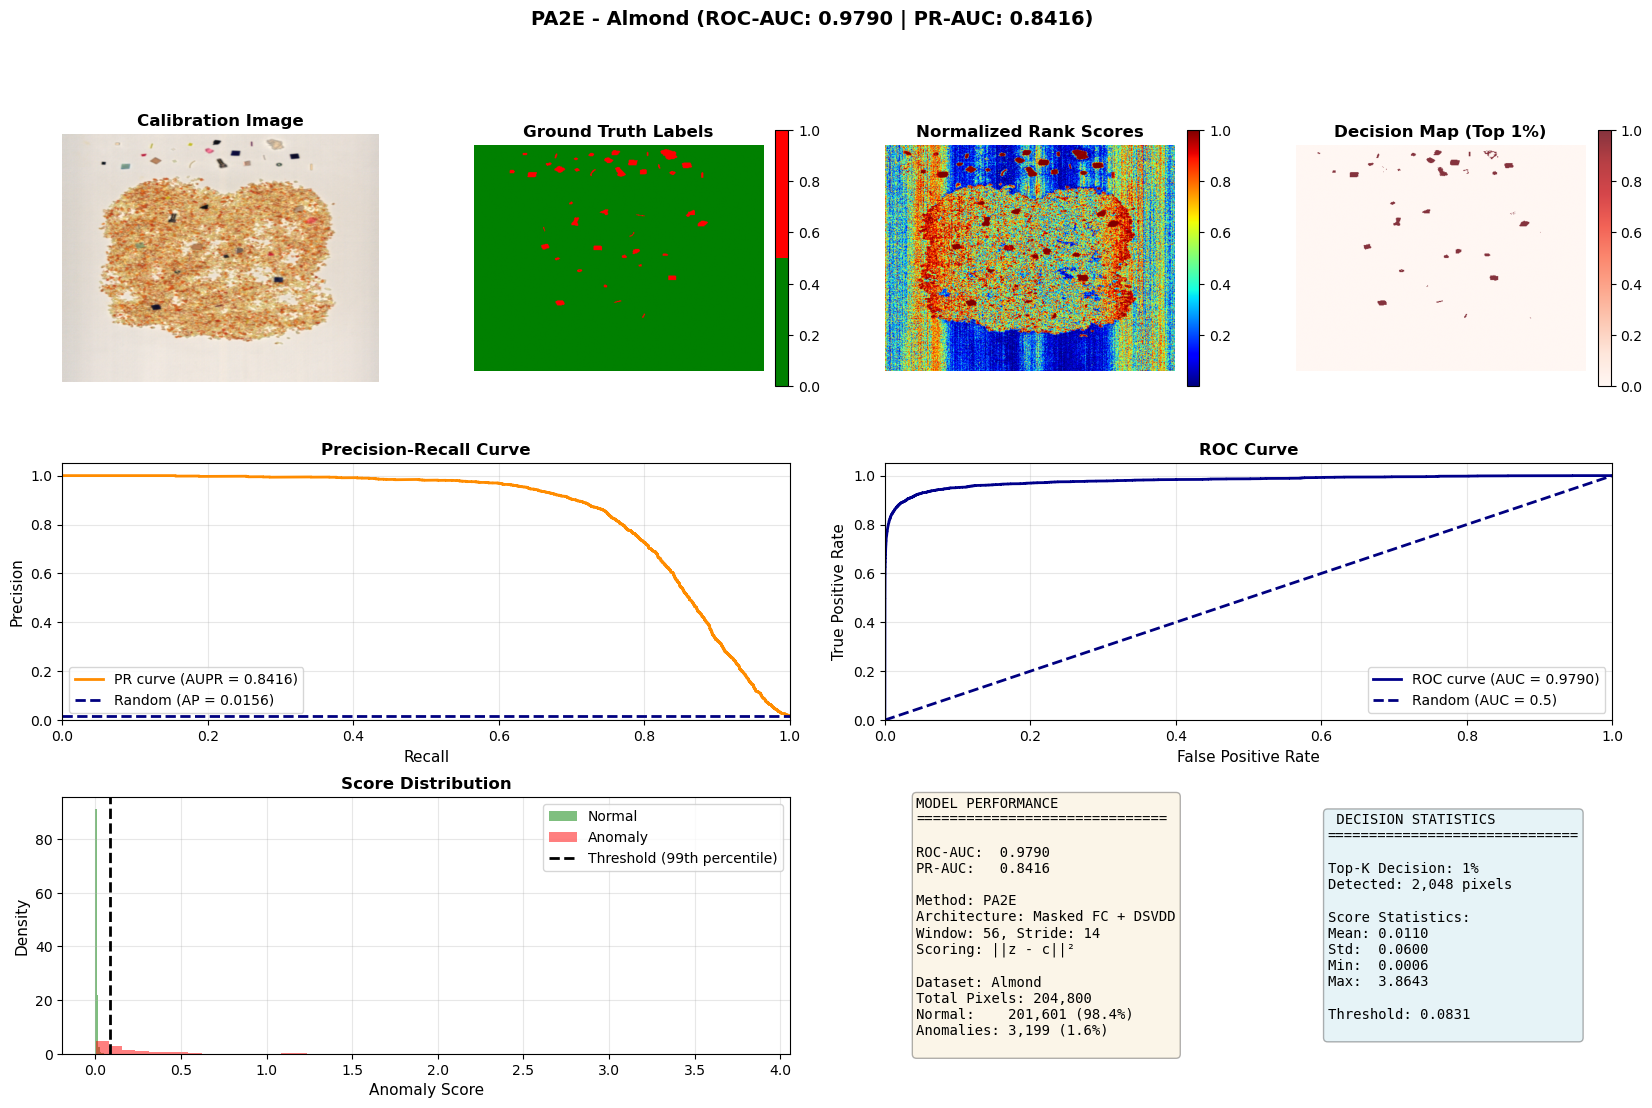


✅ Visualization complete!
   Top-K decision (1%): 2,048 pixels detected as anomalous


In [21]:
# Comprehensive visualization with multiple subplots
from scipy.stats import rankdata
from PIL import Image

# Load calibration image
calib_path = f'{base_path}/Test/image_calibration.png'

# Compute normalized rank scores for visualization
rank_scores = rankdata(scores, method="average") / len(scores)
normalized_scores = rank_scores

# Compute decision threshold (top K%)
TOP_K_PERCENT = 1  # Top 1% as anomalies
k_pixels = int(np.ceil(len(scores) * TOP_K_PERCENT / 100.0))
top_k_indices = np.argsort(-scores)[:k_pixels]
pixel_decision = np.zeros(len(scores), dtype=bool)
pixel_decision[top_k_indices] = True

# Reshape for spatial visualization
H, W = test_dataset.shape
score_map = scores.reshape(H, W)
normalized_score_map = normalized_scores.reshape(H, W)
label_map = labels.reshape(H, W)
decision_map = pixel_decision.reshape(H, W)

# Create comprehensive figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Spatial visualizations
ax1 = fig.add_subplot(gs[0, 0])
if os.path.exists(calib_path):
    calib_img = Image.open(calib_path)
    ax1.imshow(calib_img)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Calibration Image\nNot Found', ha='center', va='center', fontsize=12)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
from matplotlib.colors import ListedColormap
cmap_binary = ListedColormap(['green', 'red'])
im2 = ax2.imshow(label_map, cmap=cmap_binary)
ax2.set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(normalized_score_map, cmap='jet')
ax3.set_title('Normalized Rank Scores', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

ax4 = fig.add_subplot(gs[0, 3])
im4 = ax4.imshow(decision_map, cmap='Reds', alpha=0.8)
ax4.set_title(f'Decision Map (Top {TOP_K_PERCENT}%)', fontsize=12, fontweight='bold')
ax4.axis('off')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

# Row 2: PR and ROC curves
ax5 = fig.add_subplot(gs[1, 0:2])
precision, recall, _ = precision_recall_curve(labels, scores)
ax5.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUPR = {pr_auc:.4f})')
baseline = labels.sum() / len(labels)
ax5.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Random (AP = {baseline:.4f})')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])
ax5.set_xlabel('Recall', fontsize=11)
ax5.set_ylabel('Precision', fontsize=11)
ax5.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax5.legend(loc='best')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2:4])
fpr, tpr, _ = roc_curve(labels, scores)
ax6.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax6.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
ax6.set_xlim([0.0, 1.0])
ax6.set_ylim([0.0, 1.05])
ax6.set_xlabel('False Positive Rate', fontsize=11)
ax6.set_ylabel('True Positive Rate', fontsize=11)
ax6.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax6.legend(loc='lower right')
ax6.grid(True, alpha=0.3)

# Row 3: Distribution and statistics
ax7 = fig.add_subplot(gs[2, 0:2])
ax7.hist(scores[labels == 0], bins=50, alpha=0.5, label='Normal', color='green', density=True)
ax7.hist(scores[labels == 1], bins=50, alpha=0.5, label='Anomaly', color='red', density=True)
ax7.axvline(np.percentile(scores, 100 - TOP_K_PERCENT), color='black', linestyle='--', 
            label=f'Threshold ({100-TOP_K_PERCENT}th percentile)', linewidth=2)
ax7.set_xlabel('Anomaly Score', fontsize=11)
ax7.set_ylabel('Density', fontsize=11)
ax7.set_title('Score Distribution', fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(gs[2, 2])
stats_text_left = f"""MODEL PERFORMANCE
{'='*30}

ROC-AUC:  {roc_auc:.4f}
PR-AUC:   {pr_auc:.4f}

Method: PA2E
Architecture: Masked FC + DSVDD
Window: 56, Stride: 14
Scoring: ||z - c||²

Dataset: {food_type}
Total Pixels: {len(scores):,}
Normal:    {(labels == 0).sum():,} ({100*(labels==0).sum()/len(labels):.1f}%)
Anomalies: {(labels == 1).sum():,} ({100*(labels==1).sum()/len(labels):.1f}%)
"""
ax8.text(0.1, 0.5, stats_text_left, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax8.axis('off')

ax9 = fig.add_subplot(gs[2, 3])
stats_text_right = f""" DECISION STATISTICS
{'='*30}

Top-K Decision: {TOP_K_PERCENT}%
Detected: {pixel_decision.sum():,} pixels

Score Statistics:
Mean: {scores.mean():.4f}
Std:  {scores.std():.4f}
Min:  {scores.min():.4f}
Max:  {scores.max():.4f}

Threshold: {np.percentile(scores, 100 - TOP_K_PERCENT):.4f}
"""
ax9.text(0.1, 0.5, stats_text_right, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax9.axis('off')

plt.suptitle(f'PA2E - {food_type} (ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f})', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"\n✅ Visualization complete!")
print(f"   Top-K decision ({TOP_K_PERCENT}%): {pixel_decision.sum():,} pixels detected as anomalous")

In [22]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score

def get_embeddings(model, loader):
    model.eval()
    all_embeddings = []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Extracting embeddings'):
            if isinstance(batch, (list, tuple)):
                x, _ = batch
            else:
                x = batch
            x = x.to(device)
            z, _ = model.encode(x)
            all_embeddings.append(z.cpu())
    return torch.cat(all_embeddings).numpy()

print("\n--- Fitting k-NN (Memory Bank) ---")
# Extract embeddings for training and testing
train_embeddings = get_embeddings(model_ft, train_loader)
test_embeddings = get_embeddings(model_ft, test_loader)
test_labels = labels # from evaluate() call in previous cell

# Fit KNN on normal training data. k=1 is pure nearest neighbor. k=5 smooths noise.
knn = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
knn.fit(train_embeddings)

# Find distance to the nearest normal neighbors for the test set
distances, indices = knn.kneighbors(test_embeddings)

# Use the mean distance to the k-nearest neighbors as the anomaly score
anomaly_scores_knn = distances.mean(axis=1)

# Evaluate
roc_auc_knn = roc_auc_score(test_labels, anomaly_scores_knn)
precision_knn, recall_knn, _ = precision_recall_curve(test_labels, anomaly_scores_knn)
pr_auc_knn = auc(recall_knn, precision_knn)

print(f"KNN (k=1): ROC-AUC={roc_auc_knn:.4f}, PR-AUC={pr_auc_knn:.4f}")


--- Fitting k-NN (Memory Bank) ---


Extracting embeddings: 100%|██████████| 400/400 [00:02<00:00, 147.95it/s]


KNN (k=1): ROC-AUC=0.9812, PR-AUC=0.8631


/tmp/ipykernel_21818/3404720977.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


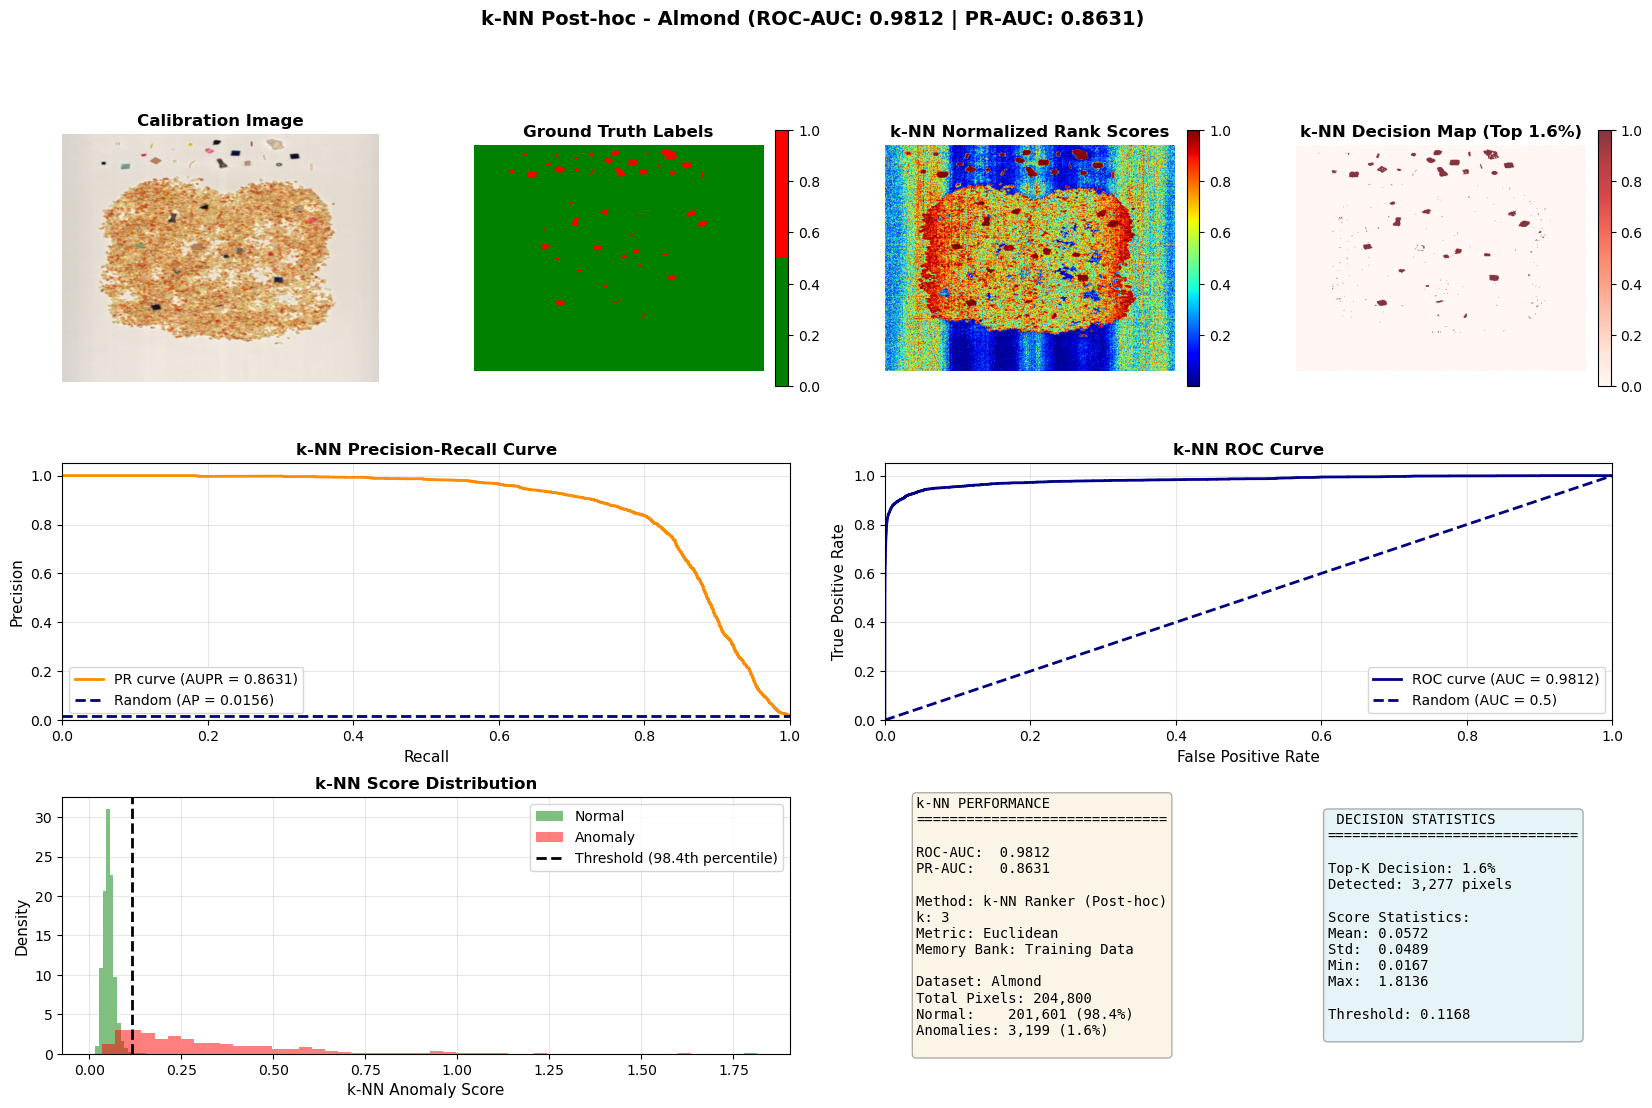


✅ k-NN Visualization complete!
Classification Report for k-NN Post-hoc Ranker:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    201601
     Anomaly       0.80      0.82      0.81      3199

    accuracy                           0.99    204800
   macro avg       0.90      0.91      0.90    204800
weighted avg       0.99      0.99      0.99    204800



In [23]:
# Visualization for k-NN Post-hoc Ranker
from scipy.stats import rankdata

# Compute normalized rank scores for visualization
rank_scores_knn = rankdata(anomaly_scores_knn, method="average") / len(anomaly_scores_knn)
normalized_scores_knn = rank_scores_knn

# Compute decision threshold (top K%)
TOP_K_PERCENT = 1.6  # Top 1% as anomalies
k_pixels = int(np.ceil(len(anomaly_scores_knn) * TOP_K_PERCENT / 100.0))
top_k_indices_knn = np.argsort(-anomaly_scores_knn)[:k_pixels]
pixel_decision_knn = np.zeros(len(anomaly_scores_knn), dtype=bool)
pixel_decision_knn[top_k_indices_knn] = True

# Reshape for spatial visualization
H, W = test_dataset.shape
score_map_knn = anomaly_scores_knn.reshape(H, W)
normalized_score_map_knn = normalized_scores_knn.reshape(H, W)
label_map = test_labels.reshape(H, W)
decision_map_knn = pixel_decision_knn.reshape(H, W)

# Create comprehensive figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Spatial visualizations
ax1 = fig.add_subplot(gs[0, 0])
calib_path = f'{base_path}/Test/image_calibration.png'
if os.path.exists(calib_path):
    calib_img = Image.open(calib_path)
    ax1.imshow(calib_img)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Calibration Image\nNot Found', ha='center', va='center', fontsize=12)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
from matplotlib.colors import ListedColormap
cmap_binary = ListedColormap(['green', 'red'])
im2 = ax2.imshow(label_map, cmap=cmap_binary)
ax2.set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(normalized_score_map_knn, cmap='jet')
ax3.set_title('k-NN Normalized Rank Scores', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

ax4 = fig.add_subplot(gs[0, 3])
im4 = ax4.imshow(decision_map_knn, cmap='Reds', alpha=0.8)
ax4.set_title(f'k-NN Decision Map (Top {TOP_K_PERCENT}%)', fontsize=12, fontweight='bold')
ax4.axis('off')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

# Row 2: PR and ROC curves
ax5 = fig.add_subplot(gs[1, 0:2])
# Use the local variables for k-NN evaluation
precision_knn_plot, recall_knn_plot, _ = precision_recall_curve(test_labels, anomaly_scores_knn)
ax5.plot(recall_knn_plot, precision_knn_plot, color='darkorange', lw=2, label=f'PR curve (AUPR = {pr_auc_knn:.4f})')
baseline = test_labels.sum() / len(test_labels)
ax5.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Random (AP = {baseline:.4f})')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])
ax5.set_xlabel('Recall', fontsize=11)
ax5.set_ylabel('Precision', fontsize=11)
ax5.set_title('k-NN Precision-Recall Curve', fontsize=12, fontweight='bold')
ax5.legend(loc='best')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2:4])
fpr_knn, tpr_knn, _ = roc_curve(test_labels, anomaly_scores_knn)
ax6.plot(fpr_knn, tpr_knn, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc_knn:.4f})')
ax6.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
ax6.set_xlim([0.0, 1.0])
ax6.set_ylim([0.0, 1.05])
ax6.set_xlabel('False Positive Rate', fontsize=11)
ax6.set_ylabel('True Positive Rate', fontsize=11)
ax6.set_title('k-NN ROC Curve', fontsize=12, fontweight='bold')
ax6.legend(loc='lower right')
ax6.grid(True, alpha=0.3)

# Row 3: Distribution and statistics
ax7 = fig.add_subplot(gs[2, 0:2])
ax7.hist(anomaly_scores_knn[test_labels == 0], bins=50, alpha=0.5, label='Normal', color='green', density=True)
ax7.hist(anomaly_scores_knn[test_labels == 1], bins=50, alpha=0.5, label='Anomaly', color='red', density=True)
ax7.axvline(np.percentile(anomaly_scores_knn, 100 - TOP_K_PERCENT), color='black', linestyle='--', 
            label=f'Threshold ({100-TOP_K_PERCENT}th percentile)', linewidth=2)
ax7.set_xlabel('k-NN Anomaly Score', fontsize=11)
ax7.set_ylabel('Density', fontsize=11)
ax7.set_title('k-NN Score Distribution', fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(gs[2, 2])
stats_text_left = f"""k-NN PERFORMANCE
{'='*30}

ROC-AUC:  {roc_auc_knn:.4f}
PR-AUC:   {pr_auc_knn:.4f}

Method: k-NN Ranker (Post-hoc)
k: 3
Metric: Euclidean
Memory Bank: Training Data

Dataset: {food_type}
Total Pixels: {len(anomaly_scores_knn):,}
Normal:    {(test_labels == 0).sum():,} ({100*(test_labels==0).sum()/len(test_labels):.1f}%)
Anomalies: {(test_labels == 1).sum():,} ({100*(test_labels==1).sum()/len(test_labels):.1f}%)
"""
ax8.text(0.1, 0.5, stats_text_left, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax8.axis('off')

ax9 = fig.add_subplot(gs[2, 3])
stats_text_right = f""" DECISION STATISTICS
{'='*30}

Top-K Decision: {TOP_K_PERCENT}%
Detected: {pixel_decision_knn.sum():,} pixels

Score Statistics:
Mean: {anomaly_scores_knn.mean():.4f}
Std:  {anomaly_scores_knn.std():.4f}
Min:  {anomaly_scores_knn.min():.4f}
Max:  {anomaly_scores_knn.max():.4f}

Threshold: {np.percentile(anomaly_scores_knn, 100 - TOP_K_PERCENT):.4f}
"""
ax9.text(0.1, 0.5, stats_text_right, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax9.axis('off')

plt.suptitle(f'k-NN Post-hoc - {food_type} (ROC-AUC: {roc_auc_knn:.4f} | PR-AUC: {pr_auc_knn:.4f})', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"\n✅ k-NN Visualization complete!")

# show acc of 1.6% top-k decision which is the real anomaly ratio in the dataset
from sklearn.metrics import classification_report
# Compute binary predictions based on the top-k decision
binary_predictions_knn = pixel_decision_knn.astype(int)
# Generate classification report
report_knn = classification_report(test_labels, binary_predictions_knn, target_names=['Normal', 'Anomaly'])
print("Classification Report for k-NN Post-hoc Ranker:")
print(report_knn)

In [24]:
from scipy.ndimage import median_filter, gaussian_filter

print("\n--- Applying Post-hoc Spatial Smoothing ---")

# 1. Reshape the 1D scores back to the 2D image
H, W = test_dataset.shape # Based on your HSIPixelDataset setup
score_map = anomaly_scores_knn.reshape(H, W)

# 2. Apply a Median Filter (kills salt-and-pepper false positives)
# A size of 3 means a 3x3 pixel window. 
smoothed_score_map = median_filter(score_map, size=3)

# Note: You can also try a Gaussian filter which blends rather than votes
# smoothed_score_map = gaussian_filter(score_map, sigma=1.0)

# 3. Flatten back to 1D for evaluation
smoothed_scores = smoothed_score_map.flatten()

# 4. Evaluate
roc_auc_smooth = roc_auc_score(test_labels, smoothed_scores)
precision_smooth, recall_smooth, _ = precision_recall_curve(test_labels, smoothed_scores)
pr_auc_smooth = auc(recall_smooth, precision_smooth)

print(f"Smoothed Hybrid KNN: ROC-AUC={roc_auc_smooth:.4f}, PR-AUC={pr_auc_smooth:.4f}")


--- Applying Post-hoc Spatial Smoothing ---
Smoothed Hybrid KNN: ROC-AUC=0.9808, PR-AUC=0.8795


/tmp/ipykernel_21818/2097570026.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


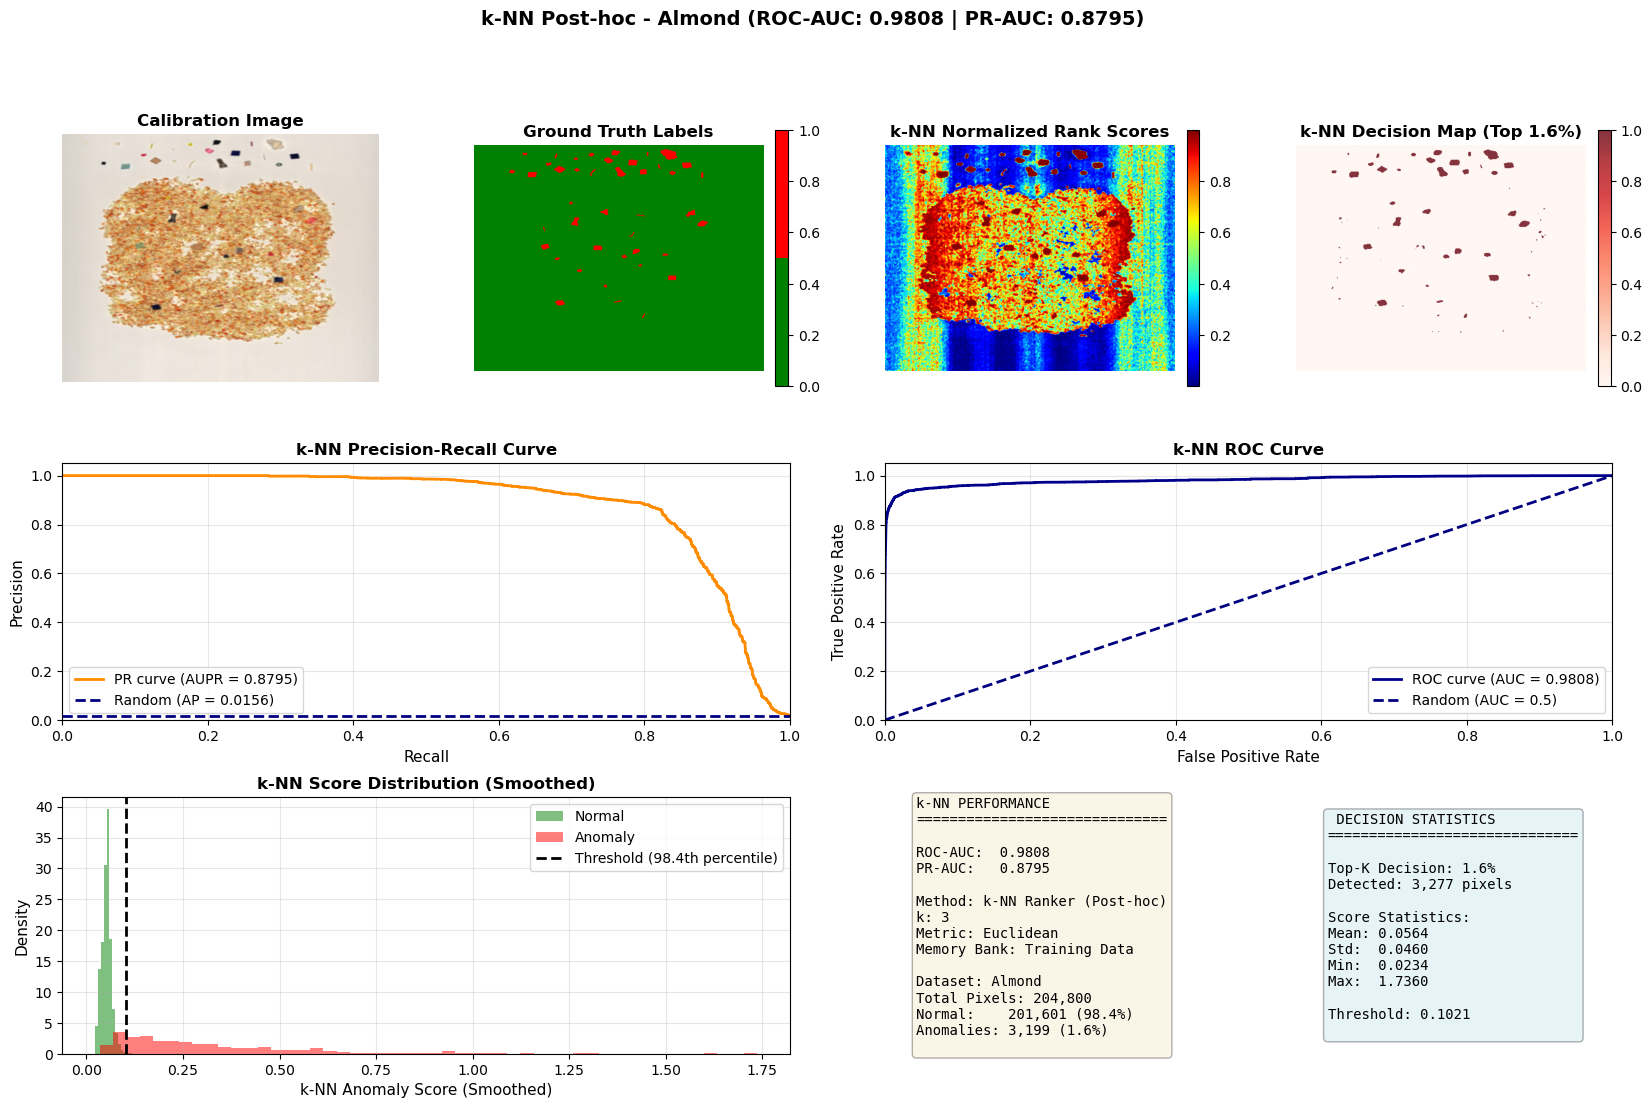


✅ k-NN Visualization complete!
Classification Report for k-NN Post-hoc Ranker:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    201601
     Anomaly       0.81      0.83      0.82      3199

    accuracy                           0.99    204800
   macro avg       0.91      0.92      0.91    204800
weighted avg       0.99      0.99      0.99    204800



In [25]:
# Visualization for k-NN Post-hoc Ranker
from scipy.stats import rankdata

# Compute normalized rank scores for visualization
rank_scores_knn = rankdata(smoothed_scores, method="average") / len(smoothed_scores)
normalized_scores_knn = rank_scores_knn

# Compute decision threshold (top K%)
TOP_K_PERCENT = 1.6  # Top 1% as anomalies
k_pixels = int(np.ceil(len(smoothed_scores) * TOP_K_PERCENT / 100.0))
top_k_indices_knn = np.argsort(-smoothed_scores)[:k_pixels]
pixel_decision_knn = np.zeros(len(smoothed_scores), dtype=bool)
pixel_decision_knn[top_k_indices_knn] = True

# Reshape for spatial visualization
H, W = test_dataset.shape
score_map_knn = smoothed_scores.reshape(H, W)
normalized_score_map_knn = normalized_scores_knn.reshape(H, W)
label_map = test_labels.reshape(H, W)
decision_map_knn = pixel_decision_knn.reshape(H, W)

# Create comprehensive figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Spatial visualizations
ax1 = fig.add_subplot(gs[0, 0])
calib_path = f'{base_path}/Test/image_calibration.png'
if os.path.exists(calib_path):
    calib_img = Image.open(calib_path)
    ax1.imshow(calib_img)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Calibration Image\nNot Found', ha='center', va='center', fontsize=12)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
from matplotlib.colors import ListedColormap
cmap_binary = ListedColormap(['green', 'red'])
im2 = ax2.imshow(label_map, cmap=cmap_binary)
ax2.set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(normalized_score_map_knn, cmap='jet')
ax3.set_title('k-NN Normalized Rank Scores', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

ax4 = fig.add_subplot(gs[0, 3])
im4 = ax4.imshow(decision_map_knn, cmap='Reds', alpha=0.8)
ax4.set_title(f'k-NN Decision Map (Top {TOP_K_PERCENT}%)', fontsize=12, fontweight='bold')
ax4.axis('off')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

# Row 2: PR and ROC curves
ax5 = fig.add_subplot(gs[1, 0:2])
# Use the local variables for k-NN evaluation
precision_knn_plot, recall_knn_plot, _ = precision_recall_curve(test_labels, smoothed_scores)
ax5.plot(recall_knn_plot, precision_knn_plot, color='darkorange', lw=2, label=f'PR curve (AUPR = {pr_auc_smooth:.4f})')
baseline = test_labels.sum() / len(test_labels)
ax5.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Random (AP = {baseline:.4f})')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])
ax5.set_xlabel('Recall', fontsize=11)
ax5.set_ylabel('Precision', fontsize=11)
ax5.set_title('k-NN Precision-Recall Curve', fontsize=12, fontweight='bold')
ax5.legend(loc='best')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2:4])
fpr_knn, tpr_knn, _ = roc_curve(test_labels, smoothed_scores)
ax6.plot(fpr_knn, tpr_knn, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc_smooth:.4f})')
ax6.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
ax6.set_xlim([0.0, 1.0])
ax6.set_ylim([0.0, 1.05])
ax6.set_xlabel('False Positive Rate', fontsize=11)
ax6.set_ylabel('True Positive Rate', fontsize=11)
ax6.set_title('k-NN ROC Curve', fontsize=12, fontweight='bold')
ax6.legend(loc='lower right')
ax6.grid(True, alpha=0.3)

# Row 3: Distribution and statistics
ax7 = fig.add_subplot(gs[2, 0:2])
ax7.hist(smoothed_scores[test_labels == 0], bins=50, alpha=0.5, label='Normal', color='green', density=True)
ax7.hist(smoothed_scores[test_labels == 1], bins=50, alpha=0.5, label='Anomaly', color='red', density=True)
ax7.axvline(np.percentile(smoothed_scores, 100 - TOP_K_PERCENT), color='black', linestyle='--', 
            label=f'Threshold ({100-TOP_K_PERCENT}th percentile)', linewidth=2)
ax7.set_xlabel('k-NN Anomaly Score (Smoothed)', fontsize=11)
ax7.set_ylabel('Density', fontsize=11)
ax7.set_title('k-NN Score Distribution (Smoothed)', fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(gs[2, 2])
stats_text_left = f"""k-NN PERFORMANCE
{'='*30}

ROC-AUC:  {roc_auc_smooth:.4f}
PR-AUC:   {pr_auc_smooth:.4f}

Method: k-NN Ranker (Post-hoc)
k: 3
Metric: Euclidean
Memory Bank: Training Data

Dataset: {food_type}
Total Pixels: {len(smoothed_scores):,}
Normal:    {(test_labels == 0).sum():,} ({100*(test_labels==0).sum()/len(test_labels):.1f}%)
Anomalies: {(test_labels == 1).sum():,} ({100*(test_labels==1).sum()/len(test_labels):.1f}%)
"""
ax8.text(0.1, 0.5, stats_text_left, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax8.axis('off')

ax9 = fig.add_subplot(gs[2, 3])
stats_text_right = f""" DECISION STATISTICS
{'='*30}

Top-K Decision: {TOP_K_PERCENT}%
Detected: {pixel_decision_knn.sum():,} pixels

Score Statistics:
Mean: {smoothed_scores.mean():.4f}
Std:  {smoothed_scores.std():.4f}
Min:  {smoothed_scores.min():.4f}
Max:  {smoothed_scores.max():.4f}

Threshold: {np.percentile(smoothed_scores, 100 - TOP_K_PERCENT):.4f}
"""
ax9.text(0.1, 0.5, stats_text_right, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax9.axis('off')

plt.suptitle(f'k-NN Post-hoc - {food_type} (ROC-AUC: {roc_auc_smooth:.4f} | PR-AUC: {pr_auc_smooth:.4f})', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"\n✅ k-NN Visualization complete!")

# show acc of 1.6% top-k decision which is the real anomaly ratio in the dataset
from sklearn.metrics import classification_report
# Compute binary predictions based on the top-k decision
binary_predictions_knn = pixel_decision_knn.astype(int)
# Generate classification report
report_knn = classification_report(test_labels, binary_predictions_knn, target_names=['Normal', 'Anomaly'])
print("Classification Report for k-NN Post-hoc Ranker:")
print(report_knn)

In [26]:
print("ROC-AUC Comparison:")
print(f"PA2E (Original): {roc_auc:.4f}")
print(f"k-NN (Original): {roc_auc_knn:.4f}")
print(f"k-NN (Smoothed): {roc_auc_smooth:.4f}")

print("\nPR-AUC Comparison:")
print(f"PA2E (Original): {pr_auc:.4f}")
print(f"k-NN (Original): {pr_auc_knn:.4f}")
print(f"k-NN (Smoothed): {pr_auc_smooth:.4f}")

ROC-AUC Comparison:
PA2E (Original): 0.9790
k-NN (Original): 0.9812
k-NN (Smoothed): 0.9808

PR-AUC Comparison:
PA2E (Original): 0.8416
k-NN (Original): 0.8631
k-NN (Smoothed): 0.8795


In [27]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score
from datetime import datetime
from scipy.ndimage import median_filter

def get_embeddings(model, loader):
    model.eval()
    all_embeddings = []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Extracting embeddings'):
            if isinstance(batch, (list, tuple)):
                x, _ = batch
            else:
                x = batch
            x = x.to(device)
            z, _ = model.encode(x)
            all_embeddings.append(z.cpu())
    return torch.cat(all_embeddings).numpy()

print("\n--- Fitting k-NN (Memory Bank) ---")
# Extract embeddings for training and testing
train_embeddings = get_embeddings(model_ft, train_loader)
test_labels = labels
H, W = test_dataset.shape

knn = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
knn.fit(train_embeddings)

start = datetime.now()
test_embeddings = get_embeddings(model_ft, test_loader)
distances, indices = knn.kneighbors(test_embeddings)
anomaly_scores_knn = distances.mean(axis=1)
score_map = anomaly_scores_knn.reshape(H, W)
smoothed_score_map = median_filter(score_map, size=3)
smoothed_scores = smoothed_score_map.flatten()
end = datetime.now()
print(f"Time taken for k-NN + Smoothing: {end - start}")



--- Fitting k-NN (Memory Bank) ---


Extracting embeddings: 100%|██████████| 400/400 [00:02<00:00, 142.26it/s]


Time taken for k-NN + Smoothing: 0:00:09.723175
